# Transform New York Taxi Dataset into Time Series Dataset
There are four taxi types with different length time in New York City (2009-2023).
1. Yellow Taxi with data range from January 1st 2009 until September 30th 2023.
2. Green Taxi with data range from  January 1st 2014 until September 30th 2023.
3. For Hire Vehicle with data range from  January 1st 2015 until September 30th 2023.
4. High Volume For Hire Vehicle with data range from  January 1st 2019 until September 30th 2023.

Each trip data was recorded and the daily data aggregation is required to create time series data for each type of taxi. There are 7 columns will be selected for data analysis, which are:
1. pick_up_time is the time passenger enter the taxi
2. drop_off_time is the time passenger get out from taxi
3. passenger_count is the number of passenger
4. trip_distance is the length of the trip
5. payment_type is the type of payment
6. total_amount is the total amount of charge for the trip
7. tip_amount is the amount of tips given by passenger

With these columns data, the data pipeline is as follow:
1. Select those 7 columns from their original tables
2. Change their column name into stardard column name
3. Delete rows data that contain NULL
4. Filter data in the range of January 1st 2009 until September 30th 2023

Then do aggregation for time series data
1. Find the number of daily/monthly trips for each taxi provider.
2. Find the average distance of each trip
3. Find the average of duration for each trip
4. Calculate percentage of tips compare to total amount paid


In [1]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt

## 1. Yellow Taxi
Unfortunately the name of column headers for yellow taxi are not the same. There will be a different in giving name title. For that reason, the column name must be standardized.

### 1.1 The 2009 Yellow Taxi Data
The column name will be changed as follow:
1. Trip_Pickup_DateTime is replaced by pick_up_time
2. Trip_Dropoff_DateTime is replaced by drop_off_time
3. Passenger_Count is replaced by passenger_count
4. Trip_Distance is replaced by trip_distance
5. Payment_Type is replaced by payment_type
6. Total_Amt is replaced by total_amount
7. Tip_Amt is replaced by tip_amount

In [2]:
#--- Read the 2009 Yellow Taxi dataset then look fer the first 5 rows ---
yellow_2009 = pl.read_parquet(r"C:\Users\ekadw\Documents\DATA\NY_Taxi\2009\yellow_taxi_2009\yellow_tripdata_2009-01.parquet")
yellow_2009.head()

vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,Rate_Code,store_and_forward,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,mta_tax,Tip_Amt,Tolls_Amt,Total_Amt
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""VTS""","""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,-73.991957,40.721567,null,null,-73.993803,40.695922,"""CASH""",8.9,0.5,null,0.0,0.0,9.4
"""VTS""","""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,-73.982102,40.73629,null,null,-73.95585,40.76803,"""Credit""",12.1,0.5,null,2.0,0.0,14.6
"""VTS""","""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,-74.002587,40.739748,null,null,-73.869983,40.770225,"""Credit""",23.7,0.0,null,4.74,0.0,28.44
"""DDS""","""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,-73.974267,40.790955,null,null,-73.996558,40.731849,"""CREDIT""",14.9,0.5,null,3.05,0.0,18.45
"""DDS""","""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,-74.00158,40.719382,null,null,-74.008378,40.72035,"""CASH""",3.7,0.0,null,0.0,0.0,3.7


In [3]:
#--- Find out all the columns name ---
yellow_2009.columns

['vendor_name',
 'Trip_Pickup_DateTime',
 'Trip_Dropoff_DateTime',
 'Passenger_Count',
 'Trip_Distance',
 'Start_Lon',
 'Start_Lat',
 'Rate_Code',
 'store_and_forward',
 'End_Lon',
 'End_Lat',
 'Payment_Type',
 'Fare_Amt',
 'surcharge',
 'mta_tax',
 'Tip_Amt',
 'Tolls_Amt',
 'Total_Amt']

### 1.2 The 2010 Yellow Taxi Data
The column name will be changed as follow:
1. pickup_datetime is replaced by pick_up_time
2. dropoff_datetime is replaced by drop_off_time
3. passenger_count is the same
4. trip_distance is the same
5. payment_type is the same
6. total_amount is the same
7. tip_amount is the same

In [4]:
#--- Read the 2010 Yellow Taxi dataset then look fer the first 5 rows ---
yellow_2010 = pl.read_parquet(r"C:\Users\ekadw\Documents\DATA\NY_Taxi\2010\yellow_taxi_2010\yellow_tripdata_2010-01.parquet")
yellow_2010.head()

vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,surcharge,mta_tax,tip_amount,tolls_amount,total_amount
str,str,str,i64,f64,f64,f64,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64
"""VTS""","""2010-01-26 07:41:00""","""2010-01-26 07:45:00""",1,0.75,-73.956778,40.76775,"""1""",null,-73.965957,40.765232,"""CAS""",4.5,0.0,0.5,0.0,0.0,5.0
"""DDS""","""2010-01-30 23:31:00""","""2010-01-30 23:46:12""",1,5.9,-73.996118,40.763932,"""1""",null,-73.981512,40.741193,"""CAS""",15.3,0.5,0.5,0.0,0.0,16.3
"""DDS""","""2010-01-18 20:22:20""","""2010-01-18 20:38:12""",1,4.0,-73.979673,40.78379,"""1""",null,-73.917852,40.87856,"""CAS""",11.7,0.5,0.5,0.0,0.0,12.7
"""VTS""","""2010-01-09 01:18:00""","""2010-01-09 01:35:00""",2,4.7,-73.977922,40.763997,"""1""",null,-73.923908,40.759725,"""CAS""",13.3,0.5,0.5,0.0,0.0,14.3
"""CMT""","""2010-01-18 19:10:14""","""2010-01-18 19:17:07""",1,0.6,-73.990924,40.734682,"""1""","""0""",-73.995511,40.739088,"""Cre""",5.3,0.0,0.5,0.87,0.0,6.67


In [5]:
#--- Find out all the columns name ---
yellow_2010.columns

['vendor_id',
 'pickup_datetime',
 'dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'pickup_longitude',
 'pickup_latitude',
 'rate_code',
 'store_and_fwd_flag',
 'dropoff_longitude',
 'dropoff_latitude',
 'payment_type',
 'fare_amount',
 'surcharge',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'total_amount']

### 1.3 Yellow Taxi Data from 2011 until 2023
The column name will be changed as follow:
1. tpep_pickup_datetime is replaced by pick_up_time
2. tpep_dropoff_datetime is replaced by drop_off_time
3. passenger_count is the same
4. trip_distance is the same
5. payment_type is the same
6. total_amount is the same
7. tip_amount is the same

In [6]:
#--- Read the 2011-2023 Yellow Taxi dataset then look fer the first 5 rows ---
yellow_2011_2023 = pl.read_parquet(r"C:\Users\ekadw\Documents\DATA\NY_Taxi\2022\yellow_taxi\yellow_tripdata_2022-01.parquet")
yellow_2011_2023.head()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
i64,datetime[ns],datetime[ns],f64,f64,f64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,2022-01-01 00:35:40,2022-01-01 00:53:29,2.0,3.8,1.0,"""N""",142,236,1,14.5,3.0,0.5,3.65,0.0,0.3,21.95,2.5,0.0
1,2022-01-01 00:33:43,2022-01-01 00:42:07,1.0,2.1,1.0,"""N""",236,42,1,8.0,0.5,0.5,4.0,0.0,0.3,13.3,0.0,0.0
2,2022-01-01 00:53:21,2022-01-01 01:02:19,1.0,0.97,1.0,"""N""",166,166,1,7.5,0.5,0.5,1.76,0.0,0.3,10.56,0.0,0.0
2,2022-01-01 00:25:21,2022-01-01 00:35:23,1.0,1.09,1.0,"""N""",114,68,2,8.0,0.5,0.5,0.0,0.0,0.3,11.8,2.5,0.0
2,2022-01-01 00:36:48,2022-01-01 01:14:20,1.0,4.3,1.0,"""N""",68,163,1,23.5,0.5,0.5,3.0,0.0,0.3,30.3,2.5,0.0


In [7]:
#--- Find out all the columns name ---
yellow_2011_2023.columns

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

## 1.4 Find the Number of Daily Trip from Yellow Taxi
The command COUNT() will be used to find out the number of daily trip.

In [14]:
query_count = """
WITH CTE_2009 AS (
    SELECT 
        Trip_Pickup_DateTime AS pick_up_time,
        Trip_Dropoff_DateTime AS drop_off_time,
        Passenger_Count AS passenger_count,
        Trip_Distance AS trip_distance,
        Payment_Type AS payment_type,
        Total_Amt AS total_amount,
        Tip_Amt AS tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi_2009/yellow_tripdata_*.parquet'
    WHERE Trip_Pickup_DateTime IS NOT NULL
        AND Trip_Dropoff_DateTime IS NOT NULL
        AND Passenger_Count IS NOT NULL
        AND Trip_Distance IS NOT NULL
        AND Payment_Type IS NOT NULL
        AND Total_Amt IS NOT NULL
        AND Tip_Amt IS NOT NULL
        AND Trip_Pickup_DateTime >= '2009-01-01' 
        AND Trip_Pickup_DateTime < '2010-10-01'
), CTE_2010 AS (
    SELECT 
        pickup_datetime AS pick_up_time,
        dropoff_datetime AS drop_off_time,
        passenger_count,
        trip_distance,
        payment_type,
        total_amount,
        tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2010/yellow_taxi_2010/yellow_tripdata_*.parquet'
    WHERE pickup_datetime IS NOT NULL
        AND dropoff_datetime IS NOT NULL
        AND passenger_count IS NOT NULL
        AND trip_distance IS NOT NULL
        AND payment_type IS NOT NULL
        AND total_amount IS NOT NULL
        AND tip_amount IS NOT NULL
        AND pickup_datetime >= '2010-01-01' 
        AND pickup_datetime < '2011-01-01'
), CTE_2011_2023 AS (
    SELECT 
        tpep_pickup_datetime AS pick_up_time,
        tpep_dropoff_datetime AS drop_off_time,
        passenger_count,
        trip_distance,
        payment_type,
        total_amount,
        tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/*/yellow_taxi/yellow_tripdata_*.parquet'
    WHERE tpep_pickup_datetime IS NOT NULL
        AND tpep_dropoff_datetime IS NOT NULL
        AND passenger_count IS NOT NULL
        AND trip_distance IS NOT NULL
        AND payment_type IS NOT NULL
        AND total_amount IS NOT NULL
        AND tip_amount IS NOT NULL
        AND tpep_pickup_datetime >= '2011-01-01' 
        AND tpep_dropoff_datetime < '2023-10-01'
), CTE_union_2009_2023 AS (
    SELECT * FROM CTE_2009
    UNION ALL
    SELECT * FROM CTE_2010
    UNION ALL
    SELECT * FROM CTE_2011_2023
), CTE_count_trip AS (
    SELECT
        DATE(pick_up_time) AS pick_up_date
    FROM CTE_union_2009_2023
)

SELECT 
    pick_up_date AS day_of_trip,
    COUNT(*) AS total_trip
FROM CTE_count_trip
GROUP BY pick_up_date
ORDER BY pick_up_date 
"""

con = duckdb.connect()
df = con.execute(query_count).fetchdf()
df.head()

,day_of_trip,total_trip
0,2009-01-01,327625
1,2009-01-02,376708
2,2009-01-03,432710
3,2009-01-04,367525
4,2009-01-05,370901


In [15]:
#--- Check the 10 last data
df.tail(10)

,day_of_trip,total_trip
5376,2023-09-21,37282
5377,2023-09-22,20
5378,2023-09-23,18
5379,2023-09-24,125
5380,2023-09-25,87644
5381,2023-09-26,107736
5382,2023-09-27,114350
5383,2023-09-28,121502
5384,2023-09-29,95916
5385,2023-09-30,106804


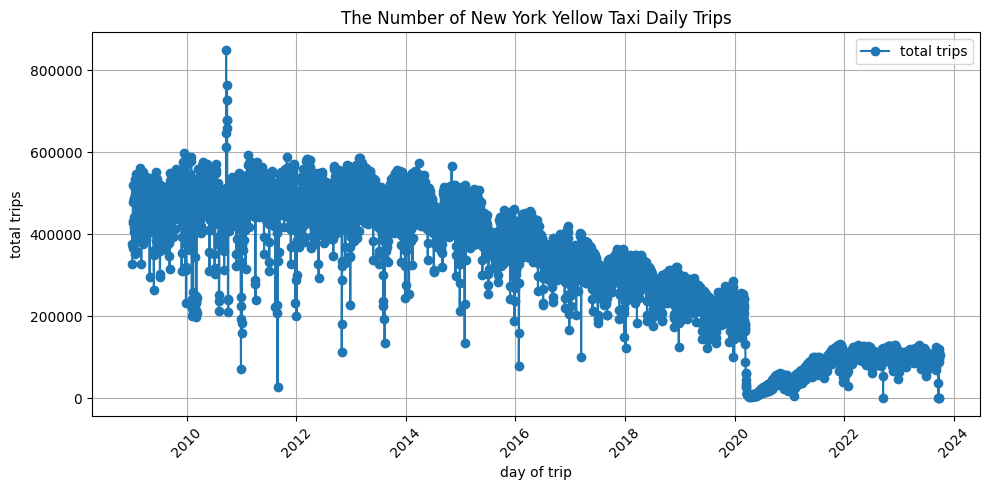

In [18]:
# Plotting
# Ensure date is datetime
import pandas as pd 
df["day_of_trip"] = pd.to_datetime(df["day_of_trip"])

# Plot
plt.figure(figsize=(10,5))
plt.plot(df["day_of_trip"], df["total_trip"], marker="o", linestyle="-", label="total trips")

plt.title("The Number of New York Yellow Taxi Daily Trips")
plt.xlabel("day of trip")
plt.ylabel("total trips")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The trend is decreasing. The biggest drop was during the covid pandemic. The daily data is too dense. Let make it to be monthly data to compare with other taxi provider.

## 2. Green Taxi

In [2]:
yellow_2009 = pl.read_parquet(r"C:\Users\ekadw\Documents\DATA\NY_Taxi\2009\yellow_taxi_2009\yellow_tripdata_2009-01.parquet")
yellow_2009.head()

vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,Rate_Code,store_and_forward,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,mta_tax,Tip_Amt,Tolls_Amt,Total_Amt
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""VTS""","""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,-73.991957,40.721567,null,null,-73.993803,40.695922,"""CASH""",8.9,0.5,null,0.0,0.0,9.4
"""VTS""","""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,-73.982102,40.73629,null,null,-73.95585,40.76803,"""Credit""",12.1,0.5,null,2.0,0.0,14.6
"""VTS""","""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,-74.002587,40.739748,null,null,-73.869983,40.770225,"""Credit""",23.7,0.0,null,4.74,0.0,28.44
"""DDS""","""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,-73.974267,40.790955,null,null,-73.996558,40.731849,"""CREDIT""",14.9,0.5,null,3.05,0.0,18.45
"""DDS""","""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,-74.00158,40.719382,null,null,-74.008378,40.72035,"""CASH""",3.7,0.0,null,0.0,0.0,3.7


In [3]:
yellow_2009.columns

['vendor_name',
 'Trip_Pickup_DateTime',
 'Trip_Dropoff_DateTime',
 'Passenger_Count',
 'Trip_Distance',
 'Start_Lon',
 'Start_Lat',
 'Rate_Code',
 'store_and_forward',
 'End_Lon',
 'End_Lat',
 'Payment_Type',
 'Fare_Amt',
 'surcharge',
 'mta_tax',
 'Tip_Amt',
 'Tolls_Amt',
 'Total_Amt']

In [4]:
query_count = """
WITH CTE_2009 AS (
    SELECT 
        Trip_Pickup_DateTime AS pick_up_time,
        Trip_Dropoff_DateTime AS drop_off_time,
        Passenger_Count AS passenger_count,
        Trip_Distance AS trip_distance,
        Payment_Type AS payment_type,
        Total_Amt AS total_amount,
        Tip_Amt AS tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi_2009/yellow_tripdata_*.parquet'
    WHERE Trip_Pickup_DateTime IS NOT NULL
        AND Trip_Dropoff_DateTime IS NOT NULL
        AND Passenger_Count IS NOT NULL
        AND Trip_Distance IS NOT NULL
        AND Payment_Type IS NOT NULL
        AND Total_Amt IS NOT NULL
        AND Tip_Amt IS NOT NULL
        AND Trip_Pickup_DateTime >= '2009-01-01' 
        AND Trip_Pickup_DateTime < '2010-10-01'
), CTE_count_trip AS (
    SELECT
        DATE(pick_up_time) AS pick_up_date
    FROM CTE_2009
)

SELECT 
    pick_up_date,
    COUNT(*)
FROM CTE_count_trip
GROUP BY pick_up_date
ORDER BY pick_up_date 
"""

con = duckdb.connect()
df = con.execute(query_count).fetchdf()
df.head()

,pick_up_date,count_star()
0,2009-01-01,327625
1,2009-01-02,376708
2,2009-01-03,432710
3,2009-01-04,367525
4,2009-01-05,370901


In [5]:
df.tail(10)

,pick_up_date,count_star()
355,2009-12-22,455090
356,2009-12-23,456094
357,2009-12-24,382635
358,2009-12-25,233221
359,2009-12-26,320616
360,2009-12-27,312947
361,2009-12-28,375455
362,2009-12-29,447016
363,2009-12-30,429635
364,2009-12-31,461201


In [6]:
query_count = """
WITH CTE_2009 AS (
    SELECT 
        Trip_Pickup_DateTime AS pick_up_time,
        Trip_Dropoff_DateTime AS drop_off_time,
        Passenger_Count AS passenger_count,
        Trip_Distance AS trip_distance,
        Payment_Type AS payment_type,
        Total_Amt AS total_amount,
        Tip_Amt AS tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi_2009/yellow_tripdata_*.parquet'
    WHERE Trip_Pickup_DateTime IS NOT NULL
        AND Trip_Dropoff_DateTime IS NOT NULL
        AND Passenger_Count IS NOT NULL
        AND Trip_Distance IS NOT NULL
        AND Payment_Type IS NOT NULL
        AND Total_Amt IS NOT NULL
        AND Tip_Amt IS NOT NULL
        AND Trip_Pickup_DateTime >= '2009-01-01' 
        AND Trip_Pickup_DateTime < '2010-01-01'
), CTE_count_trip AS (
    SELECT
        DATE(pick_up_time) AS pick_up_date
    FROM CTE_2009
)

SELECT 
    COUNT(*)
FROM CTE_count_trip
"""

con = duckdb.connect()
df = con.execute(query_count).fetchdf()
df.head()

,count_star()
0,170896055


In [7]:
yellow_2010 = pl.read_parquet(r"C:\Users\ekadw\Documents\DATA\NY_Taxi\2010\yellow_taxi_2010\yellow_tripdata_2010-01.parquet")
yellow_2010.head()

vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,surcharge,mta_tax,tip_amount,tolls_amount,total_amount
str,str,str,i64,f64,f64,f64,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64
"""VTS""","""2010-01-26 07:41:00""","""2010-01-26 07:45:00""",1,0.75,-73.956778,40.76775,"""1""",null,-73.965957,40.765232,"""CAS""",4.5,0.0,0.5,0.0,0.0,5.0
"""DDS""","""2010-01-30 23:31:00""","""2010-01-30 23:46:12""",1,5.9,-73.996118,40.763932,"""1""",null,-73.981512,40.741193,"""CAS""",15.3,0.5,0.5,0.0,0.0,16.3
"""DDS""","""2010-01-18 20:22:20""","""2010-01-18 20:38:12""",1,4.0,-73.979673,40.78379,"""1""",null,-73.917852,40.87856,"""CAS""",11.7,0.5,0.5,0.0,0.0,12.7
"""VTS""","""2010-01-09 01:18:00""","""2010-01-09 01:35:00""",2,4.7,-73.977922,40.763997,"""1""",null,-73.923908,40.759725,"""CAS""",13.3,0.5,0.5,0.0,0.0,14.3
"""CMT""","""2010-01-18 19:10:14""","""2010-01-18 19:17:07""",1,0.6,-73.990924,40.734682,"""1""","""0""",-73.995511,40.739088,"""Cre""",5.3,0.0,0.5,0.87,0.0,6.67


In [8]:
yellow_2010.columns

['vendor_id',
 'pickup_datetime',
 'dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'pickup_longitude',
 'pickup_latitude',
 'rate_code',
 'store_and_fwd_flag',
 'dropoff_longitude',
 'dropoff_latitude',
 'payment_type',
 'fare_amount',
 'surcharge',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'total_amount']

In [9]:
query_count = """
WITH CTE_2010 AS (
    SELECT 
        pickup_datetime AS pick_up_time,
        dropoff_datetime AS drop_off_time,
        passenger_count,
        trip_distance,
        payment_type,
        total_amount,
        tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2010/yellow_taxi_2010/yellow_tripdata_*.parquet'
    WHERE pickup_datetime IS NOT NULL
        AND dropoff_datetime IS NOT NULL
        AND passenger_count IS NOT NULL
        AND trip_distance IS NOT NULL
        AND payment_type IS NOT NULL
        AND total_amount IS NOT NULL
        AND tip_amount IS NOT NULL
        AND pickup_datetime >= '2010-01-01' 
        AND pickup_datetime < '2011-01-01'
), CTE_count_trip AS (
    SELECT
        DATE(pick_up_time) AS pick_up_date
    FROM CTE_2010
)

SELECT 
    pick_up_date,
    COUNT(*)
FROM CTE_count_trip
GROUP BY pick_up_date
ORDER BY pick_up_date 
"""

con = duckdb.connect()
df = con.execute(query_count).fetchdf()
df.head()

,pick_up_date,count_star()
0,2010-01-01,401856
1,2010-01-02,410622
2,2010-01-03,389569
3,2010-01-04,399321
4,2010-01-05,445264


In [10]:
df.tail(10)

,pick_up_date,count_star()
355,2010-12-22,485123
356,2010-12-23,459871
357,2010-12-24,361296
358,2010-12-25,226051
359,2010-12-26,193529
360,2010-12-27,72025
361,2010-12-28,247546
362,2010-12-29,332715
363,2010-12-30,372902
364,2010-12-31,430727


In [11]:
query_count = """
WITH CTE_2010 AS (
    SELECT 
        pickup_datetime AS pick_up_time,
        dropoff_datetime AS drop_off_time,
        passenger_count,
        trip_distance,
        payment_type,
        total_amount,
        tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2010/yellow_taxi_2010/yellow_tripdata_*.parquet'
    WHERE pickup_datetime IS NOT NULL
        AND dropoff_datetime IS NOT NULL
        AND passenger_count IS NOT NULL
        AND trip_distance IS NOT NULL
        AND payment_type IS NOT NULL
        AND total_amount IS NOT NULL
        AND tip_amount IS NOT NULL
        AND pickup_datetime >= '2010-01-01' 
        AND pickup_datetime < '2011-01-01'
), CTE_count_trip AS (
    SELECT
        DATE(pick_up_time) AS pick_up_date
    FROM CTE_2010
)

SELECT 
    COUNT(*)
FROM CTE_count_trip
"""

con = duckdb.connect()
df = con.execute(query_count).fetchdf()
df.head()

,count_star()
0,169001153


In [19]:
yellow_2023 = pl.read_parquet(r"C:\Users\ekadw\Documents\DATA\NY_Taxi\2022\yellow_taxi\yellow_tripdata_2022-01.parquet")
yellow_2023.head()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
i64,datetime[ns],datetime[ns],f64,f64,f64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,2022-01-01 00:35:40,2022-01-01 00:53:29,2.0,3.8,1.0,"""N""",142,236,1,14.5,3.0,0.5,3.65,0.0,0.3,21.95,2.5,0.0
1,2022-01-01 00:33:43,2022-01-01 00:42:07,1.0,2.1,1.0,"""N""",236,42,1,8.0,0.5,0.5,4.0,0.0,0.3,13.3,0.0,0.0
2,2022-01-01 00:53:21,2022-01-01 01:02:19,1.0,0.97,1.0,"""N""",166,166,1,7.5,0.5,0.5,1.76,0.0,0.3,10.56,0.0,0.0
2,2022-01-01 00:25:21,2022-01-01 00:35:23,1.0,1.09,1.0,"""N""",114,68,2,8.0,0.5,0.5,0.0,0.0,0.3,11.8,2.5,0.0
2,2022-01-01 00:36:48,2022-01-01 01:14:20,1.0,4.3,1.0,"""N""",68,163,1,23.5,0.5,0.5,3.0,0.0,0.3,30.3,2.5,0.0


In [5]:
query = """
WITH CTE_jan_2023 AS (
    SELECT 
        tpep_pickup_datetime AS pick_up_time,
        tpep_dropoff_datetime AS drop_off_time,
        passenger_count,
        trip_distance,
        payment_type,
        total_amount,
        tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2023/yellow_taxi/yellow_tripdata_2023-01.parquet'
)

SELECT 
    *
FROM CTE_jan_2023
"""

con = duckdb.connect()
df = con.execute(query).fetchdf()
df.head()

,pick_up_time,drop_off_time,passenger_count,trip_distance,payment_type,total_amount,tip_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,14.30,0.00
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,16.90,4.00
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,34.90,15.00
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,20.85,0.00
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,19.68,3.28


In [44]:
query_count = """
WITH CTE_2023 AS (
    SELECT 
        tpep_pickup_datetime AS pick_up_time,
        tpep_dropoff_datetime AS drop_off_time,
        passenger_count,
        trip_distance,
        payment_type,
        total_amount,
        tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2023/yellow_taxi/yellow_tripdata_*.parquet'
    WHERE tpep_pickup_datetime IS NOT NULL
        AND tpep_dropoff_datetime IS NOT NULL
        AND passenger_count IS NOT NULL
        AND trip_distance IS NOT NULL
        AND payment_type IS NOT NULL
        AND total_amount IS NOT NULL
        AND tip_amount IS NOT NULL
), CTE_count_trip AS (
    SELECT
        DATE(pick_up_time) AS pick_up_date
    FROM CTE_2023
)

SELECT 
    pick_up_date,
    COUNT(*)
FROM CTE_count_trip
WHERE pick_up_date >= '2009-01-01' AND pick_up_date < '2023-10-01'
GROUP BY pick_up_date
ORDER BY pick_up_date DESC
"""

con = duckdb.connect()
df = con.execute(query_count).fetchdf()
df.head()

,pick_up_date,count_star()
0,2023-09-30,108446
1,2023-09-29,95916
2,2023-09-28,121503
3,2023-09-27,114350
4,2023-09-26,107736


In [46]:
df.head(50)

,pick_up_date,count_star()
0,2023-09-30,108446
1,2023-09-29,95916
2,2023-09-28,121503
3,2023-09-27,114350
4,2023-09-26,107736
5,2023-09-25,87644
6,2023-09-24,125
7,2023-09-23,18
8,2023-09-22,20
9,2023-09-21,37282


In [ ]:
query_count = """
WITH CTE_2023 AS (
    SELECT 
        tpep_pickup_datetime AS pick_up_time,
        tpep_dropoff_datetime AS drop_off_time,
        passenger_count,
        trip_distance,
        payment_type,
        total_amount,
        tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi_*/yellow_tripdata_*.parquet'
    WHERE tpep_pickup_datetime IS NOT NULL
        AND tpep_dropoff_datetime IS NOT NULL
        AND passenger_count IS NOT NULL
        AND trip_distance IS NOT NULL
        AND payment_type IS NOT NULL
        AND total_amount IS NOT NULL
        AND tip_amount IS NOT NULL
), CTE_count_trip AS (
    SELECT
        DATE(pick_up_time) AS pick_up_date
    FROM CTE_2023
)

SELECT 
    COUNT(*)
FROM CTE_count_trip
WHERE pick_up_date >= '2009-01-01' AND pick_up_date < '2023-10-01'
"""

con = duckdb.connect()
df = con.execute(query_count).fetchdf()
df.head()

In [48]:
query_count = """
WITH CTE_2023 AS (
    SELECT 
        tpep_pickup_datetime AS pick_up_time,
        tpep_dropoff_datetime AS drop_off_time,
        passenger_count,
        trip_distance,
        payment_type,
        total_amount,
        tip_amount
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/*/yellow_taxi/yellow_tripdata_*.parquet'
    WHERE tpep_pickup_datetime IS NOT NULL
        AND tpep_dropoff_datetime IS NOT NULL
        AND passenger_count IS NOT NULL
        AND trip_distance IS NOT NULL
        AND payment_type IS NOT NULL
        AND total_amount IS NOT NULL
        AND tip_amount IS NOT NULL
), CTE_count_trip AS (
    SELECT
        DATE(pick_up_time) AS pick_up_date
    FROM CTE_2023
)

SELECT 
    COUNT(*)
FROM CTE_count_trip
WHERE pick_up_date >= '2009-01-01' AND pick_up_date < '2023-10-01'
"""

con = duckdb.connect()
df = con.execute(query_count).fetchdf()
df.head()

,count_star()
0,1381927977
